# Модуль 1. Хранение HR-данных и формирование отчетов на их основе

Создаем датасет со следующими данными:
- Id_сотрудника
- ФИО
- Должность
- Пол
- Дата приема на работу
- Список навыков
- Заработная плата
- Размер ежемесячного бонуса
- Количество подчиненных

In [1]:
employees_data = [
    {
        "id": 1,
        "fio": "Галкин Иван Денисович",
        "position": "Программист",
        "gender": "М",
        "hire_date": "2023-05-15",
        "skills": ["Python", "SQL", "Git"],
        "salary": 150000,
        "bonus": 15000,
        "subordinates": 2
    },
    {
        "id": 2,
        "fio": "Петрова Мария Сергеевна",
        "position": "Аналитик",
        "gender": "Ж",
        "hire_date": "2024-11-20",
        "skills": ["SQL", "PowerBI", "Python"],
        "salary": 165000,
        "bonus": 12000,
        "subordinates": 0
    },
    {
        "id": 3,
        "fio": "Якушев Алексей Алексеевич",
        "position": "Project-менеджер",
        "gender": "М",
        "hire_date": "2020-03-10",
        "skills": ["Excel", "Agile", "Jira"],
        "salary": 180000,
        "bonus": 20000,
        "subordinates": 5
    },
    {
        "id": 4,
        "fio": "Козлова Анна Владимировна",
        "position": "Дизайнер",
        "gender": "Ж",
        "hire_date": "2025-07-01",
        "skills": ["Figma", "Photoshop", "UX/UI"],
        "salary": 140000,
        "bonus": 10000,
        "subordinates": 1
    },
    {
        "id": 5,
        "fio": "Николаев Дмитрий Сергеевич",
        "position": "Тестировщик",
        "gender": "М",
        "hire_date": "2023-01-15",
        "skills": ["Selenium", "JUnit", "Postman"],
        "salary": 130000,
        "bonus": 8000,
        "subordinates": 4
    },
    {
        "id": 6,
        "fio": "Федотова Екатерина Игоревна",
        "position": "Руководитель направления",
        "gender": "Ж",
        "hire_date": "2019-08-22",
        "skills": ["Excel", "Agile", "1C"],
        "salary": 250000,
        "bonus": 30000,
        "subordinates": 20
    },
    {
        "id": 7,
        "fio": "Григорьев Павел Андреевич",
        "position": "DevOps-инженер",
        "gender": "М",
        "hire_date": "2022-04-05",
        "skills": ["Docker", "Kubernetes", "AWS"],
        "salary": 190000,
        "bonus": 18000,
        "subordinates": 7
    },
    {
        "id": 8,
        "fio": "Орлова Светлана Михайловна",
        "position": "Маркетолог",
        "gender": "Ж",
        "hire_date": "2021-09-12",
        "skills": ["SMM", "Google Analytics", "Копирайтинг"],
        "salary": 135000,
        "bonus": 9000,
        "subordinates": 3
    },
    {
        "id": 9,
        "fio": "Васильев Игорь Николаевич",
        "position": "Системный администратор",
        "gender": "М",
        "hire_date": "2025-02-03",
        "skills": ["Linux", "Windows Server", "Сети"],
        "salary": 155000,
        "bonus": 13000,
        "subordinates": 0
    },
    {
        "id": 10,
        "fio": "Морозова Татьяна Викторовна",
        "position": "Бизнес-аналитик",
        "gender": "Ж",
        "hire_date": "2023-03-18",
        "skills": ["BPMN", "UML", "SQL"],
        "salary": 160000,
        "bonus": 14000,
        "subordinates": 2
    }
]

В качестве формата хранения данных был выбран **список словарей**, так как он обеспечивает удобный доступ по ключам, изменяемый (в отличие от кортежей) и поддерживает разные типы данных. 

In [2]:
employees_data

[{'id': 1,
  'fio': 'Галкин Иван Денисович',
  'position': 'Программист',
  'gender': 'М',
  'hire_date': '2023-05-15',
  'skills': ['Python', 'SQL', 'Git'],
  'salary': 150000,
  'bonus': 15000,
  'subordinates': 2},
 {'id': 2,
  'fio': 'Петрова Мария Сергеевна',
  'position': 'Аналитик',
  'gender': 'Ж',
  'hire_date': '2024-11-20',
  'skills': ['SQL', 'PowerBI', 'Python'],
  'salary': 165000,
  'bonus': 12000,
  'subordinates': 0},
 {'id': 3,
  'fio': 'Якушев Алексей Алексеевич',
  'position': 'Project-менеджер',
  'gender': 'М',
  'hire_date': '2020-03-10',
  'skills': ['Excel', 'Agile', 'Jira'],
  'salary': 180000,
  'bonus': 20000,
  'subordinates': 5},
 {'id': 4,
  'fio': 'Козлова Анна Владимировна',
  'position': 'Дизайнер',
  'gender': 'Ж',
  'hire_date': '2025-07-01',
  'skills': ['Figma', 'Photoshop', 'UX/UI'],
  'salary': 140000,
  'bonus': 10000,
  'subordinates': 1},
 {'id': 5,
  'fio': 'Николаев Дмитрий Сергеевич',
  'position': 'Тестировщик',
  'gender': 'М',
  'hire_da

## Функция №1
Создаем индивидуальные сообщения для сотрудников с их персональными данными (ФИО, должность, доход, количество подчиненных).

1. Указываем обращение (уважаемый/-ая) в зависимости от гендера сотрудника. 
2. Рассчитываем общий доход сотрудника (зарплата + бонус). 
3. Возвращаем готовый текст сообщения для рассылки.

In [3]:
def generate_message(employee_id: int) -> str:
    """
    Генерирует персонализированное сообщение для сотрудника по его id
    
    Args:
        employee_id (int): ID сотрудника
        
    Returns:
        str: Текст уведомления
    """
    for emp in employees_data:
        if emp["id"] == employee_id:
            total_income = emp["salary"] + emp["bonus"]
            greeting = "Уважаемый" if emp["gender"] == "М" else "Уважаемая"
            
            return (f"{greeting} {emp['fio']}!\n"
                   f"Ваша должность: {emp['position']}\n"
                   f"Общий доход: {total_income} руб.\n"
                   f"Количество подчиненных: {emp['subordinates']}\n"
                   f"\nСпасибо за вашу работу!")
    return "Сотрудник не найден!"

In [4]:
print(generate_message(1))

Уважаемый Галкин Иван Денисович!
Ваша должность: Программист
Общий доход: 165000 руб.
Количество подчиненных: 2

Спасибо за вашу работу!


In [5]:
print(generate_message(2))

Уважаемая Петрова Мария Сергеевна!
Ваша должность: Аналитик
Общий доход: 177000 руб.
Количество подчиненных: 0

Спасибо за вашу работу!


In [6]:
print(generate_message(11))

Сотрудник не найден!


## Функция №2
Анализируем гендерный состав сотрудников в зависимости от количества подчиненных.

1. Фильтруем сотрудников по минимальному количеству подчиненных.
2. Рассчитываем процентное соотношение мужчин и женщин.

In [7]:
def gender_statistics(min_subordinates: int = 5) -> dict:
    """
    Рассчитывает гендерное разнообразие сотрудников руководящих должностей 
    
    Args:
        min_subordinates (int): Минимальное количество подчиненных
        
    Returns:
        dict: Статистика по гендерам
    """
    filtered_employees = [emp for emp in employees_data if emp["subordinates"] >= min_subordinates]
    
    if not filtered_employees:
        return {"М": 0.0, "Ж": 0.0}
    
    male_count = sum(1 for emp in filtered_employees if emp["gender"] == "М")
    female_count = sum(1 for emp in filtered_employees if emp["gender"] == "Ж")
    total = len(filtered_employees)
    
    return {
        "М": round(male_count / total * 100, 2),
        "Ж": round(female_count / total * 100, 2)
    }

In [8]:
stats = gender_statistics(5)
print(f"Доля мужчин среди руководителей: {stats['М']}%")
print(f"Доля женщин среди руководителей: {stats['Ж']}%")

Доля мужчин среди руководителей: 66.67%
Доля женщин среди руководителей: 33.33%


In [9]:
stats = gender_statistics(0)
print(f"Доля мужчин среди всех сотрудников: {stats['М']}%")
print(f"Доля женщин среди всех сотрудников: {stats['Ж']}%")

Доля мужчин среди всех сотрудников: 50.0%
Доля женщин среди всех сотрудников: 50.0%


## Функция 3
Выводим всех сотрудников, обладающих заданным набором навыков.

1. Ищем сотрудников, у которых есть все указанные навыки. 
2. Возвращаем ФИО, должность и полный список навыков подходящих сотрудников.

In [10]:
def find_employees_by_skills(required_skills: list) -> str:
    """
    Находит сотрудников, обладающих всеми указанными навыками
    
    Args:
        required_skills (list): Список требуемых навыков
        
    Returns:
        str: Список сотрудников с указанными навыками
    """
    result = []
    for emp in employees_data:
        if all(skill in emp["skills"] for skill in required_skills):
            result.append(emp)
    
    if not result:
        return "Сотрудники с указанными навыками не найдены!"
    
    output = "Сотрудники с навыками: " + ", ".join(required_skills) + "\n"
    output += "" * 30 + "\n"
    
    for i, emp in enumerate(result, 1):
        output += f"{i}. {emp['fio']}\n"
        output += f"   Должность: {emp['position']}\n"
        output += f"   Навыки: {', '.join(emp['skills'])}\n"
        output += "" * 30 + "\n"
    
    return output

In [11]:
print(find_employees_by_skills(["SQL", "Python"]))

Сотрудники с навыками: SQL, Python

1. Галкин Иван Денисович
   Должность: Программист
   Навыки: Python, SQL, Git

2. Петрова Мария Сергеевна
   Должность: Аналитик
   Навыки: SQL, PowerBI, Python




## Функция №4
Рассчитываем основные статистические показатели по зарплатам сотрудников.

1. Считаем среднюю, медианную, максимальную и минимальную зарплаты.
2. Считаем средний размер бонуса.
3. Рассчитываем общий доход сотрудников и определяем средний доход. 

In [12]:
def salary_statistics() -> dict:
    """
    Рассчитывает статистику по зарплатам сотрудников
    
    Returns:
        dict: Статистика по зарплатам
    """
    salaries = [emp["salary"] for emp in employees_data]
    bonuses = [emp["bonus"] for emp in employees_data]
    total_incomes = [emp["salary"] + emp["bonus"] for emp in employees_data]
    
    def calculate_mean(data):
        return sum(data) / len(data)
    
    def calculate_median(data):
        sorted_data = sorted(data)
        n = len(sorted_data)
        if n % 2 == 0:
            return (sorted_data[n//2 - 1] + sorted_data[n//2]) / 2
        else:
            return sorted_data[n//2]
    
    return {
        "Средняя зарплата": calculate_mean(salaries),
        "Медианная зарплата": calculate_median(salaries),
        "Максимальная зарплата": max(salaries),
        "Минимальная зарплата": min(salaries),
        "Средний бонус": calculate_mean(bonuses),
        "Средний общий доход": calculate_mean(total_incomes)
    }

In [13]:
salary_stats = salary_statistics()

for key, value in salary_stats.items():
    print(f"{key}: {value:.0f}")

Средняя зарплата: 165500
Медианная зарплата: 157500
Максимальная зарплата: 250000
Минимальная зарплата: 130000
Средний бонус: 14900
Средний общий доход: 180400


##  Функция №5
Находим сотрудников, принятых на работу за последние годы, для анализа текучести кадров и динамики найма.

1. Находим сотрудников, удовлетворяющих критерию по указанной дате найма.
2. Возвращаем список подходящих сотрудников с датами их найма.
3. Рассчитываем общее количество сотрудников, принятых на работу в указанном периоде.  

In [14]:
def get_recent_hires(years: int = 3) -> str:
    """
    Находит сотрудников, принятых за последние N лет
    
    Args:
        years (int): Количество лет
        
    Returns:
        str: Форматированный список недавно принятых сотрудников
    """
    current_year = 2025
    result = []
    
    for emp in employees_data:
        hire_year = int(emp["hire_date"][:4])
        if current_year - hire_year <= years:
            result.append(emp)
    
    if not result:
        return f"Сотрудники не найдены."
    
    output = f"Сотрудники, принятые за последние {years} года:\n"
    output += "" * 50 + "\n"
    
    for i, emp in enumerate(result, 1):
        output += f"{i}. {emp['fio']} ({emp['hire_date']})\n"
    
    output += f"\nВсего: {len(result)} сотрудников."
    return output

In [15]:
print(get_recent_hires(3))

Сотрудники, принятые за последние 3 года:

1. Галкин Иван Денисович (2023-05-15)
2. Петрова Мария Сергеевна (2024-11-20)
3. Козлова Анна Владимировна (2025-07-01)
4. Николаев Дмитрий Сергеевич (2023-01-15)
5. Григорьев Павел Андреевич (2022-04-05)
6. Васильев Игорь Николаевич (2025-02-03)
7. Морозова Татьяна Викторовна (2023-03-18)

Всего: 7 сотрудников.


# Модуль 2. Чтение HR-данных из файла, их обработка и запись в файл 

Создаем текстовый файл со следующими данными:
- id
- ФИО
- Должность
- Оклад
- Дата приема

In [16]:
with open('employees.txt', 'w', encoding='utf-8') as f:
    f.write("""Идентификатор: 1
ФИО: Галкин Иван Денисович
Должность: программист
Оклад: 150000
Дата приема: 2023-05-15

Идентификатор: 2
ФИО: Петрова Мария Сергеевна
Должность: аналитик
Оклад: 165000
Дата приема: 2024-11-20

Идентификатор: 3
ФИО: Якушев Алексей Алексеевич
Должность: project-менеджер
Оклад: 180000
Дата приема: 2020-03-10

Идентификатор: 4
ФИО: Козлова Анна Владимировна
Должность: дизайнер
Оклад: 140000
Дата приема: 2025-07-01

Идентификатор: 5
ФИО: Николаев Дмитрий Сергеевич
Должность: тестировщик
Оклад: 130000
Дата приема: 2023-01-15

Идентификатор: 6
ФИО: Федотова Екатерина Игоревна
Должность: руководитель направления
Оклад: 250000
Дата приема: 2019-08-22

Идентификатор: 7
ФИО: Григорьев Павел Андреевич
Должность: DevOpsинженер
Оклад: 190000
Дата приема: 2022-04-05

Идентификатор: 8
ФИО: Орлова Светлана Михайловна
Должность: маркетолог
Оклад: 135000
Дата приема: 2021-09-12

Идентификатор: 9
ФИО: Васильев Игорь Николаевич
Должность: системный администратор
Оклад: 155000
Дата приема: 2025-02-03

Идентификатор: 10
ФИО: Морозова Татьяна Викторовна
Должность: бизнес-аналитик
Оклад: 160000
Дата приема: 2023-03-18
""")

In [17]:
def read_file(filename: str) -> list:
    """
    Читает данные о сотрудниках из текстового файла
    
    Args:
        filename (str): Имя файла
        
    Returns:
        list: Список словарей с данными сотрудников
    """
    employees = []
    current_employee = {}
    
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_employee:
                    employees.append(current_employee)
                    current_employee = {}
                continue
                
            if ':' in line:
                key, value = line.split(':', 1)
                key = key.strip()
                value = value.strip()
                
                if key == "Идентификатор":
                    current_employee["id"] = int(value)
                elif key == "ФИО":
                    current_employee["fio"] = value
                elif key == "Должность":
                    current_employee["position"] = value
                elif key == "Оклад":
                    current_employee["salary"] = int(value)
                elif key == "Дата приема":
                    current_employee["hire_date"] = value
    
    if current_employee:
        employees.append(current_employee)
    
    return employees

In [19]:
employees_from_file = read_file('employees.txt')
employees_from_file

[{'id': 1,
  'fio': 'Галкин Иван Денисович',
  'position': 'программист',
  'salary': 150000,
  'hire_date': '2023-05-15'},
 {'id': 2,
  'fio': 'Петрова Мария Сергеевна',
  'position': 'аналитик',
  'salary': 165000,
  'hire_date': '2024-11-20'},
 {'id': 3,
  'fio': 'Якушев Алексей Алексеевич',
  'position': 'project-менеджер',
  'salary': 180000,
  'hire_date': '2020-03-10'},
 {'id': 4,
  'fio': 'Козлова Анна Владимировна',
  'position': 'дизайнер',
  'salary': 140000,
  'hire_date': '2025-07-01'},
 {'id': 5,
  'fio': 'Николаев Дмитрий Сергеевич',
  'position': 'тестировщик',
  'salary': 130000,
  'hire_date': '2023-01-15'},
 {'id': 6,
  'fio': 'Федотова Екатерина Игоревна',
  'position': 'руководитель направления',
  'salary': 250000,
  'hire_date': '2019-08-22'},
 {'id': 7,
  'fio': 'Григорьев Павел Андреевич',
  'position': 'DevOpsинженер',
  'salary': 190000,
  'hire_date': '2022-04-05'},
 {'id': 8,
  'fio': 'Орлова Светлана Михайловна',
  'position': 'маркетолог',
  'salary': 135

### Формируем отчет, содержащий следующие данные:
- Число сотрудников
- Средний оклад
- Доля сотрудников, принятых на работу за последние 3 года

In [20]:
total_employees = len(employees_from_file)

print(f"Число сотрудников: {total_employees}")

Число сотрудников: 10


In [21]:
salaries = [emp["salary"] for emp in employees_from_file]
average_salary = sum(salaries) / total_employees

print(f"Средний оклад: {average_salary:.0f}")

Средний оклад: 165500


In [22]:
current_year = 2024
recent_hires_count = 0
for emp in employees_from_file:
    hire_year = int(emp["hire_date"][:4])
    if current_year - hire_year <= 3:
        recent_hires_count += 1

recent_hires_ratio = recent_hires_count / total_employees

print(f"Доля сотрудников, принятых на работу за последние 3 года: {recent_hires_ratio:.0%}")

Доля сотрудников, принятых на работу за последние 3 года: 80%


### Добавляем отчет в конец текстового файла с данными о сотрудниках

In [23]:
with open('employees.txt', 'a', encoding='utf-8') as f:
    f.write(f"\n\nСтатистика по сотрудникам\n")
    f.write(f"Число сотрудников: {total_employees}\n")
    f.write(f"Средний оклад: {average_salary:.0f}\n")
    f.write(f"Доля сотрудников, принятых на работу за последние 3 года: {recent_hires_ratio:.0%}\n")

In [24]:
with open('employees.txt', 'r', encoding='utf-8') as f:
    file_content = f.read()
    print(file_content)

Идентификатор: 1
ФИО: Галкин Иван Денисович
Должность: программист
Оклад: 150000
Дата приема: 2023-05-15

Идентификатор: 2
ФИО: Петрова Мария Сергеевна
Должность: аналитик
Оклад: 165000
Дата приема: 2024-11-20

Идентификатор: 3
ФИО: Якушев Алексей Алексеевич
Должность: project-менеджер
Оклад: 180000
Дата приема: 2020-03-10

Идентификатор: 4
ФИО: Козлова Анна Владимировна
Должность: дизайнер
Оклад: 140000
Дата приема: 2025-07-01

Идентификатор: 5
ФИО: Николаев Дмитрий Сергеевич
Должность: тестировщик
Оклад: 130000
Дата приема: 2023-01-15

Идентификатор: 6
ФИО: Федотова Екатерина Игоревна
Должность: руководитель направления
Оклад: 250000
Дата приема: 2019-08-22

Идентификатор: 7
ФИО: Григорьев Павел Андреевич
Должность: DevOpsинженер
Оклад: 190000
Дата приема: 2022-04-05

Идентификатор: 8
ФИО: Орлова Светлана Михайловна
Должность: маркетолог
Оклад: 135000
Дата приема: 2021-09-12

Идентификатор: 9
ФИО: Васильев Игорь Николаевич
Должность: системный администратор
Оклад: 155000
Дата приема:

# Модуль 3. Расчёт показателей эффективности работы в numpy

Создаем массив numpy со следующими данными о сотрудниках:
- количество выполненных задач
- % выполнения KPI  
- время выполнения задач (в часах)
- оценка от контрагентов 
- количество предложенных идей 

In [25]:
import numpy as np

In [26]:
performance_data = np.array([
    [45, 92, 160, 4.8, 3],  # сотрудник 1
    [38, 88, 175, 4.5, 2],  # сотрудник 2
    [52, 95, 145, 4.9, 5],  # сотрудник 3
    [41, 90, 168, 4.6, 1],  # сотрудник 4
    [48, 93, 152, 4.7, 4],  # сотрудник 5
    [55, 96, 140, 5.0, 6],  # сотрудник 6
    [36, 87, 180, 4.4, 1],  # сотрудник 7
    [50, 94, 148, 4.8, 3],  # сотрудник 8
    [43, 89, 165, 4.5, 2],  # сотрудник 9
    [47, 91, 155, 4.7, 3]   # сотрудник 10
])

performance_data

array([[ 45. ,  92. , 160. ,   4.8,   3. ],
       [ 38. ,  88. , 175. ,   4.5,   2. ],
       [ 52. ,  95. , 145. ,   4.9,   5. ],
       [ 41. ,  90. , 168. ,   4.6,   1. ],
       [ 48. ,  93. , 152. ,   4.7,   4. ],
       [ 55. ,  96. , 140. ,   5. ,   6. ],
       [ 36. ,  87. , 180. ,   4.4,   1. ],
       [ 50. ,  94. , 148. ,   4.8,   3. ],
       [ 43. ,  89. , 165. ,   4.5,   2. ],
       [ 47. ,  91. , 155. ,   4.7,   3. ]])

### Рассчитываем метрики эффективности сотрудников:
1. Общая производительность (нормализованное среднее по всем метрикам эффективности).
2. Эффективность выполнения задач (отношение количества выполненных задач к времени их выполнения).
3. Индекс качества работы (произведение KPI и оценок от контрагентов).
4. Нормализованный показатель количества предложенных идей.
5. Интегральный показатель эффективности сотрудника (взвешенная сумма всех метрик).

In [27]:
def calculate_performance_metrics(data: np.ndarray) -> dict:
    """
    Рассчитывает различные метрики эффективности работы сотрудников
    
    Args:
        data (np.ndarray): Массив с показателями эффективности
        
    Returns:
        dict: Словарь с рассчитанными метриками
    """
    metrics = {}
    
    # Общая производительность 
    normalized_data = data / np.max(data, axis=0)
    metrics["performance_score"] = np.mean(normalized_data, axis=1)
    
    # Эффективность выполнения задач
    metrics["tasks_score"] = data[:, 0] / data[:, 2] 
    
    # Индекс качества работы
    metrics["quality_score"] = (data[:, 1] / 100) * data[:, 3]
    
    # Количество предложенных идей
    metrics["idea_score"] = data[:, 4] / np.max(data[:, 4])
    
    # Интегральный показатель эффективности
    weights = np.array([0.3, 0.25, 0.2, 0.15, 0.1])
    normalized_metrics = data / np.max(data, axis=0)
    metrics["integral_score"] = np.dot(normalized_metrics, weights)
    
    return metrics

In [28]:
performance_metrics = calculate_performance_metrics(performance_data)

for i in range(len(performance_data)):
    print(f"\nСотрудник {i+1}:")
    print(f"  Общая производительность: {performance_metrics['performance_score'][i]:.2f}")
    print(f"  Эффективность выполнения задач: {performance_metrics['tasks_score'][i]:.2f}")
    print(f"  Индекс качества работы: {performance_metrics['quality_score'][i]:.2f}")
    print(f"  Количество предложенных идей: {performance_metrics['idea_score'][i]:.2f}")
    print(f"  Интегральный показатель эффективности: {performance_metrics['integral_score'][i]:.2f}")


Сотрудник 1:
  Общая производительность: 0.83
  Эффективность выполнения задач: 0.28
  Индекс качества работы: 4.42
  Количество предложенных идей: 0.50
  Интегральный показатель эффективности: 0.86

Сотрудник 2:
  Общая производительность: 0.76
  Эффективность выполнения задач: 0.22
  Индекс качества работы: 3.96
  Количество предложенных идей: 0.33
  Интегральный показатель эффективности: 0.80

Сотрудник 3:
  Общая производительность: 0.91
  Эффективность выполнения задач: 0.36
  Индекс качества работы: 4.66
  Количество предложенных идей: 0.83
  Интегральный показатель эффективности: 0.92

Сотрудник 4:
  Общая производительность: 0.74
  Эффективность выполнения задач: 0.24
  Индекс качества работы: 4.14
  Количество предложенных идей: 0.17
  Интегральный показатель эффективности: 0.80

Сотрудник 5:
  Общая производительность: 0.86
  Эффективность выполнения задач: 0.32
  Индекс качества работы: 4.37
  Количество предложенных идей: 0.67
  Интегральный показатель эффективности: 0.88


Дополнительно посчитаем статистику по метрикам среди всех сотрудников.

In [29]:
print(f"Средняя общая производительность: {np.mean(performance_metrics['performance_score']):.2f}")
print(f"Максимальная эффективность задач: {np.max(performance_metrics['tasks_score']):.2f}")
print(f"Средний индекс качества работы: {np.mean(performance_metrics['quality_score']):.2f}")
print(f"Количество предложенных идей: {np.sum(performance_data[:, 4])}")

Средняя общая производительность: 0.82
Максимальная эффективность задач: 0.39
Средний индекс качества работы: 4.30
Количество предложенных идей: 30.0


# Модуль 4. Анализ и визуализация данных об отделах в pandas

Создаем CSV-файл со следующими данными об отделах:
- id
- название отдела
- количество сотрудников
- годовой бюджет
- количество активных проектов
- местоположение
- опыт руководства
- индекс удовлетворенности сотрудников
- уровень развития технологий
- уровень роста 
- количество часов обучения

In [30]:
import pandas as pd

In [34]:
departments_data = {
    'id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'name': ['IT', 'Маркетинг', 'Финансы', 'HR', 'Продажи', 'Разработка', 'Аналитика', 'Поддержка', 'Дизайн', 'Тестирование'],
    'employees_count': [15, 8, 6, 5, 12, 20, 7, 10, 4, 8],
    'annual_budget': [5000000, 2000000, 1500000, 1200000, 3000000, 8000000, 1800000, 2500000, 900000, 1600000],
    'projects_count': [8, 5, 3, 2, 6, 12, 4, 7, 3, 5],
    'location': ['Москва', 'Москва', 'Санкт-Петербург', 'Москва', 'Казань', 'Москва', 'Санкт-Петербург', 'Москва', 'Санкт-Петербург', 'Москва'],
    'manager_experience': [10, 7, 12, 8, 6, 15, 9, 5, 4, 7],
    'employee_satisfaction': [4.2, 3.8, 4.5, 4.1, 3.9, 4.3, 4.4, 3.7, 4.6, 4.0],
    'technology_level': ['Высокий', 'Средний', 'Низкий', 'Низкий', 'Средний', 'Высокий', 'Высокий', 'Средний', 'Высокий', 'Средний'],
    'growth_rate': [15.5, 8.2, 5.7, 3.2, 12.8, 25.3, 18.1, 6.4, 9.7, 11.2],
    'training_hours': [40, 20, 25, 35, 18, 45, 30, 22, 38, 28]
}

df_departments = pd.DataFrame(departments_data)
df_departments.to_csv('departments.csv', index=False, encoding='utf-8')


### Читаем данные из CSV-файла

In [35]:
df = pd.read_csv('departments.csv')

In [36]:
df.head()

,id,name,employees_count,annual_budget,projects_count,location,manager_experience,employee_satisfaction,technology_level,growth_rate,training_hours
0,1,IT,15,5000000,8,Москва,10,4.2,Высокий,15.5,40
1,2,Маркетинг,8,2000000,5,Москва,7,3.8,Средний,8.2,20
2,3,Финансы,6,1500000,3,Санкт-Петербург,12,4.5,Низкий,5.7,25
3,4,HR,5,1200000,2,Москва,8,4.1,Низкий,3.2,35
4,5,Продажи,12,3000000,6,Казань,6,3.9,Средний,12.8,18


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     10 non-null     int64  
 1   name                   10 non-null     object 
 2   employees_count        10 non-null     int64  
 3   annual_budget          10 non-null     int64  
 4   projects_count         10 non-null     int64  
 5   location               10 non-null     object 
 6   manager_experience     10 non-null     int64  
 7   employee_satisfaction  10 non-null     float64
 8   technology_level       10 non-null     object 
 9   growth_rate            10 non-null     float64
 10  training_hours         10 non-null     int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 1012.0+ bytes


In [38]:
df.describe()

,id,employees_count,annual_budget,projects_count,manager_experience,employee_satisfaction,growth_rate,training_hours
count,10.00000,10.000000,1.000000e+01,10.000000,10.000,10.000000,10.00000,10.000000
mean,5.50000,9.500000,2.750000e+06,5.500000,8.300,4.150000,11.61000,30.100000
std,3.02765,4.949747,2.183906e+06,2.953341,3.335,0.302765,6.61924,9.134185
min,1.00000,4.000000,9.000000e+05,2.000000,4.000,3.700000,3.20000,18.000000
25%,3.25000,6.250000,1.525000e+06,3.250000,6.250,3.925000,6.85000,22.750000
50%,5.50000,8.000000,1.900000e+06,5.000000,7.500,4.150000,10.45000,29.000000
75%,7.75000,11.500000,2.875000e+06,6.750000,9.750,4.375000,14.82500,37.250000
max,10.00000,20.000000,8.000000e+06,12.000000,15.000,4.600000,25.30000,45.000000


### Создаем сводные таблицы:
1. Средний бюджет на сотрудника по локациям
2. Статистика по уровню технологий
3. Бюджет и удовлетворенность по отделам

In [43]:
tab_1 = pd.pivot_table(df, 
                       values='annual_budget', 
                       index='location', 
                       aggfunc=['mean', 'count'])

# Форматируем числа без экспоненты
pd.options.display.float_format = '{:,.0f}'.format
tab_1

,mean,count
,annual_budget,annual_budget
location,,
Казань,"3,000,000",1
Москва,"3,383,333",6
Санкт-Петербург,"1,400,000",3


In [44]:
tab_2 = pd.pivot_table(df, 
                       values=['employees_count', 'projects_count', 'employee_satisfaction'], 
                       index='technology_level', 
                       aggfunc={'employees_count': 'mean', 
                               'projects_count': 'mean', 
                               'employee_satisfaction': 'mean'})
tab_2

,employee_satisfaction,employees_count,projects_count
technology_level,,,
Высокий,4,12,7
Низкий,4,6,2
Средний,4,10,6


In [45]:
tab_3 = pd.pivot_table(df, 
                       values=['annual_budget', 'employee_satisfaction'], 
                       index='name', 
                       aggfunc='mean')
tab_3

,annual_budget,employee_satisfaction
name,,
HR,"1,200,000",4
IT,"5,000,000",4
Аналитика,"1,800,000",4
Дизайн,"900,000",5
Маркетинг,"2,000,000",4
Поддержка,"2,500,000",4
Продажи,"3,000,000",4
Разработка,"8,000,000",4
Тестирование,"1,600,000",4


### Строим графики:
1. Распределение количества сотрудников по отделам
2. Годовой бюджет по отделам
3. Соотношние удовлетворенности сотрудников и бюджета на сотрудника
4. Распределение отделов по уровню технологий
5. Темпы роста по отделам
6. Связь между опытом руководителя и удовлетворенностью

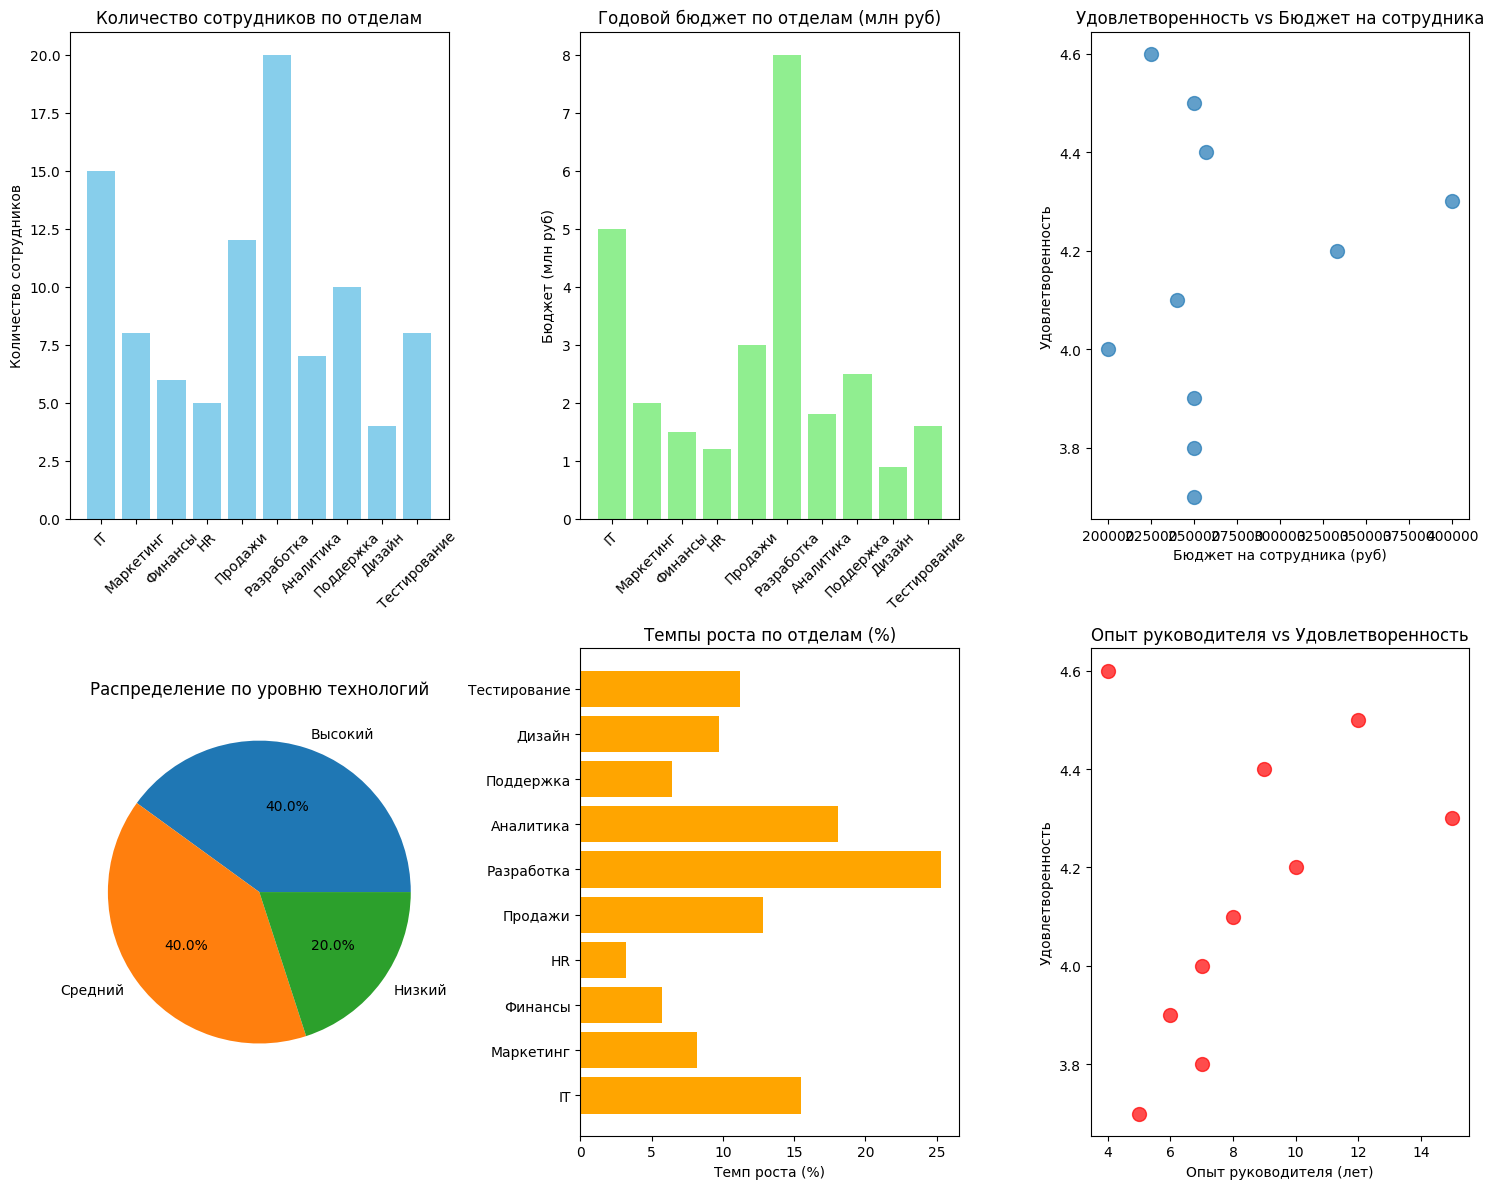

In [46]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 12))

# Распределение количества сотрудников по отделам
plt.subplot(2, 3, 1)
plt.bar(df['name'], df['employees_count'], color='skyblue')
plt.title('Количество сотрудников по отделам')
plt.xticks(rotation=45)
plt.ylabel('Количество сотрудников')

# Годовой бюджет по отделам
plt.subplot(2, 3, 2)
plt.bar(df['name'], df['annual_budget'] / 1000000, color='lightgreen')
plt.title('Годовой бюджет по отделам (млн руб)')
plt.xticks(rotation=45)
plt.ylabel('Бюджет (млн руб)')

# Связь между бюджетом на сотрудника и удовлетворенностью
plt.subplot(2, 3, 3)
budget_per_employee = df['annual_budget'] / df['employees_count']
plt.scatter(budget_per_employee, df['employee_satisfaction'], s=100, alpha=0.7)
plt.title('Удовлетворенность vs Бюджет на сотрудника')
plt.xlabel('Бюджет на сотрудника (руб)')
plt.ylabel('Удовлетворенность')

# Распределение по уровню технологий
plt.subplot(2, 3, 4)
tech_counts = df['technology_level'].value_counts()
plt.pie(tech_counts.values, labels=tech_counts.index, autopct='%1.1f%%')
plt.title('Распределение по уровню технологий')

# Темпы роста по отделам
plt.subplot(2, 3, 5)
plt.barh(df['name'], df['growth_rate'], color='orange')
plt.title('Темпы роста по отделам (%)')
plt.xlabel('Темп роста (%)')

# Связь между опытом руководителя и удовлетворенностью
plt.subplot(2, 3, 6)
plt.scatter(df['manager_experience'], df['employee_satisfaction'], s=100, alpha=0.7, color='red')
plt.title('Опыт руководителя vs Удовлетворенность')
plt.xlabel('Опыт руководителя (лет)')
plt.ylabel('Удовлетворенность')

plt.tight_layout()
plt.show()

Из построенных графиков можно сделать следующие выводы: 
- Отделы с высоким уровнем технологий имеют больше сотрудников и проектов
- Наблюдается слабая положительная корреляция между бюджетом на сотрудника и удовлетворенностью
- Отделы в Москве имеют в среднем больший бюджет
- Опыт руководителя положительно влияет на удовлетворенность сотрудников
- Отделы разработки и IT показывают наибольшие темпы роста

# Модуль 5. Система подбора сотрудников для корпоративного обучения

Используем тот же датасет, что и в первом модуле:
- Id_сотрудника
- ФИО
- Должность
- Пол
- Дата приема на работу
- Список навыков
- Заработная плата
- Размер ежемесячного бонуса
- Количество подчиненных

In [56]:
employees_data

[{'id': 1,
  'fio': 'Галкин Иван Денисович',
  'position': 'Программист',
  'gender': 'М',
  'hire_date': '2023-05-15',
  'skills': ['Python', 'SQL', 'Git'],
  'salary': 150000,
  'bonus': 15000,
  'subordinates': 2},
 {'id': 2,
  'fio': 'Петрова Мария Сергеевна',
  'position': 'Аналитик',
  'gender': 'Ж',
  'hire_date': '2024-11-20',
  'skills': ['SQL', 'PowerBI', 'Python'],
  'salary': 165000,
  'bonus': 12000,
  'subordinates': 0},
 {'id': 3,
  'fio': 'Якушев Алексей Алексеевич',
  'position': 'Project-менеджер',
  'gender': 'М',
  'hire_date': '2020-03-10',
  'skills': ['Excel', 'Agile', 'Jira'],
  'salary': 180000,
  'bonus': 20000,
  'subordinates': 5},
 {'id': 4,
  'fio': 'Козлова Анна Владимировна',
  'position': 'Дизайнер',
  'gender': 'Ж',
  'hire_date': '2025-07-01',
  'skills': ['Figma', 'Photoshop', 'UX/UI'],
  'salary': 140000,
  'bonus': 10000,
  'subordinates': 1},
 {'id': 5,
  'fio': 'Николаев Дмитрий Сергеевич',
  'position': 'Тестировщик',
  'gender': 'М',
  'hire_da

Создаем функцию, которая решает задачу автоматического отбора сотрудников для корпоративного обучения. 

Система анализирует навыки сотрудников, их эффективность, мотивацию и стаж работы, чтобы рекомендовать наиболее подходящих кандидатов  для каждого учебного курса.
    
1. Анализируем данных о сотрудниках.
2. Сохраняем информацию о доступных корпоративных курсах в текстовый файл.
3. Расчитываем приоритетные баллы для обучения на основе эффективности, мотивации и стажа работы.
4. Создаем дашборд со статистикой по кандидатам для обучения. 
5. Подбираем наиболее подходящих по навыкам и баллам обучения кандидатов на корпоративные курсы.

In [57]:
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')  # не показываем предупреждения

### Считаем статистику сотрудников

In [58]:
total_employees = len(employees_data)
avg_salary = sum(emp["salary"] for emp in employees_data) / total_employees

print(f"Всего сотрудников: {total_employees}")
print(f"Средняя зарплата: {avg_salary:.0f} руб.\n")

Всего сотрудников: 10
Средняя зарплата: 165500.00 руб.



### Создаем файл с курсами

In [71]:
def save_courses_to_file():
    """
    Создание файла с информацией о корпоративных курсах
    
    Returns:
        list: Список строк с данными о курсах
    """
    courses_data = [
        "Data Science|Python,SQL,ML,Statistics",
        "DevOps Engineering|Docker,Kubernetes,Linux,AWS",
        "Project Management|Agile,Jira,Excel,Leadership",
        "UX/UI Design|Figma,Photoshop,UX/UI,Prototyping",
        "Business Analytics|SQL,PowerBI,Excel,Statistics"
    ]
    
    with open("corporate_courses.txt", "w", encoding="utf-8") as f:
        for course in courses_data:
            f.write(course + "\n")
    
    return courses_data

In [73]:
courses_data = save_courses_to_file()
courses_data

['Data Science|Python,SQL,ML,Statistics',
 'DevOps Engineering|Docker,Kubernetes,Linux,AWS',
 'Project Management|Agile,Jira,Excel,Leadership',
 'UX/UI Design|Figma,Photoshop,UX/UI,Prototyping',
 'Business Analytics|SQL,PowerBI,Excel,Statistics']

### Рассчитываем баллы обучения

In [61]:
def calculate_training_priority(employees_data):
    """
    Расчет приоритетных баллов для обучения на основе стажа работы
    
    Args:
        employees_data (list): Список словарей с данными сотрудников
        
    Returns:
        numpy.ndarray: Массив с баллами обучения для каждого сотрудника
    """
    
    # Рассчитываем стаж работы для каждого сотрудника
    experience_years = np.array([2025 - int(emp["hire_date"][:4]) for emp in employees_data])
    
    # Нормализуем стаж (чем меньше стаж, тем выше приоритет для обучения)
    experience_priority = 1 - (experience_years / np.max(experience_years))
    
    # Дополнительные факторы: зарплата и кол-во подчиненных как индикаторы опыта
    salaries = np.array([emp["salary"] for emp in employees_data])
    subordinates = np.array([emp["subordinates"] for emp in employees_data])
    
    # Нормализуем дополнительные факторы
    salary_normalized = salaries / np.max(salaries)
    subordinates_normalized = subordinates / np.max(subordinates) if np.max(subordinates) > 0 else subordinates
    
    # Веса для критериев: стаж (главный критерий), зарплата, кол-во подчиненных
    weights = np.array([0.6, 0.25, 0.15])
    
    # Рассчитываем общий балл для обучения
    training_scores = (experience_priority * weights[0] + 
                      salary_normalized * weights[1] + 
                      subordinates_normalized * weights[2])
    
    print(f"Средний балл: {np.mean(training_scores):.3f}")
    print(f"Максимальный балл: {np.max(training_scores):.3f}")
    print(f"Минимальный балл: {np.min(training_scores):.3f}")
    
    return training_scores

In [62]:
training_scores = calculate_training_priority(employees_data)

Средний балл: 0.548
Максимальный балл: 0.755
Минимальный балл: 0.317


### Создаем DataFrame
Добавляем в DataFrame новые колонки: 
- количество лет опыта
- балл за обучение
- общий доход

In [63]:
df = pd.DataFrame(employees_data)

df['experience_years'] = 2025 - pd.to_datetime(df['hire_date']).dt.year
df['training_score'] = training_scores
df['total_income'] = df['salary'] + df['bonus']

### Визуализируем данные

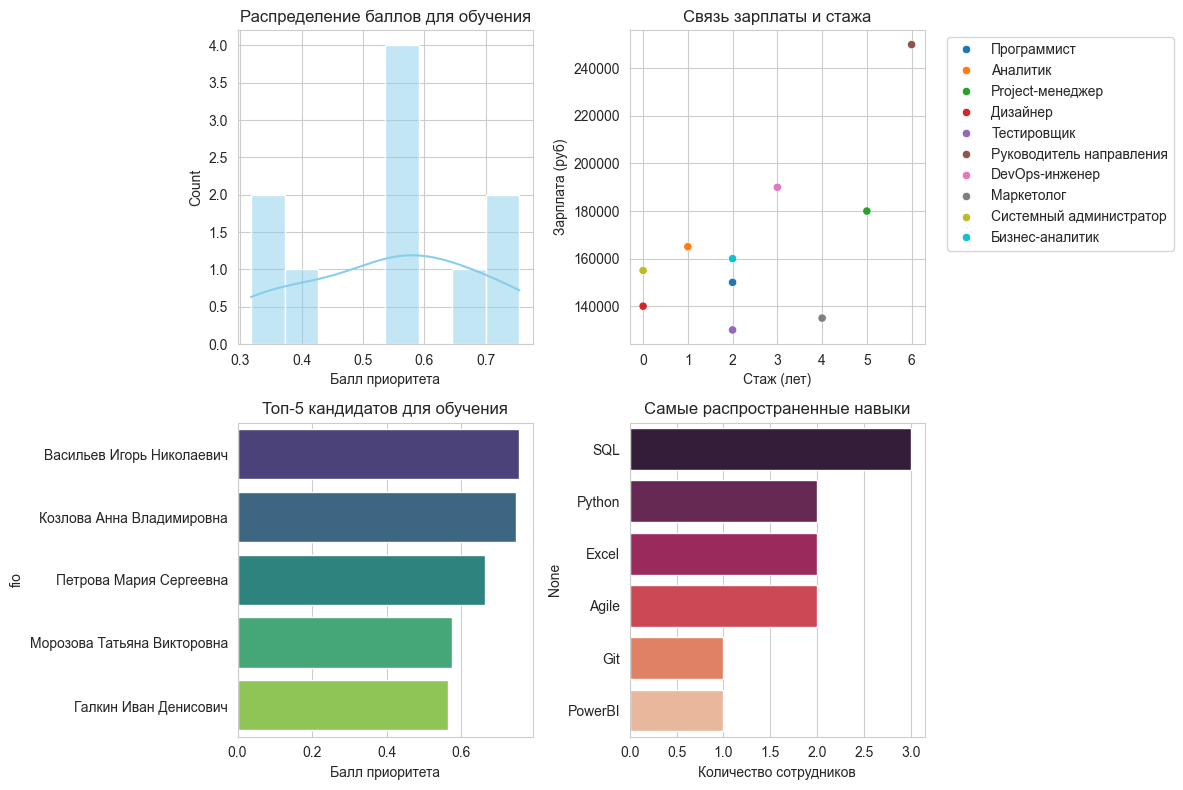

In [64]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Распределение баллов для обучения
plt.subplot(2, 2, 1)
sns.histplot(df['training_score'], kde=True, color='skyblue', bins=8)
plt.title('Распределение баллов для обучения')
plt.xlabel('Балл приоритета')

# Связь зарплаты и стажа
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='experience_years', y='salary', hue='position')
plt.title('Связь зарплаты и стажа')
plt.xlabel('Стаж (лет)')
plt.ylabel('Зарплата (руб)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Топ-5 кандидатов для обучения
plt.subplot(2, 2, 3)
top_candidates = df.nlargest(5, 'training_score')[['fio', 'training_score']]
sns.barplot(data=top_candidates, x='training_score', y='fio', palette='viridis')
plt.title('Топ-5 кандидатов для обучения')
plt.xlabel('Балл приоритета')

# Навыки сотрудников
plt.subplot(2, 2, 4)

all_skills = [skill for emp in employees_data for skill in emp['skills']]
skill_counts = pd.Series(all_skills).value_counts().head(6)

sns.barplot(x=skill_counts.values, y=skill_counts.index, palette='rocket')
plt.title('Самые распространенные навыки')
plt.xlabel('Количество сотрудников')

plt.tight_layout()
plt.show()

### Создаем систему подбора кандидатов на курсы

In [91]:
def select_training_candidates(df, courses_data):
    """
    Подбор кандидатов для корпоративных курсов на основе навыков
    
    Args:
        df (pandas.DataFrame): DataFrame с данными сотрудников
        courses_data (list): Список данных о курсах
        
    Returns:
        list: Список строк с отчетом по подбору кандидатов
    """
    
    training_report = []
    
    # Читаем данные о курсах
    courses = {}
    for course_line in courses_data:
        if "|" in course_line:
            name, skills_str = course_line.split("|")
            courses[name] = [skill.strip() for skill in skills_str.split(",")]
    
    # Для каждого курса подбираем кандидатов
    for course_name, required_skills in courses.items():
        training_report.append(f"КУРС: {course_name}")
        training_report.append(f"Требуемые навыки: {', '.join(required_skills)}")
        training_report.append("-" * 50)
        
        candidates_for_course = []
        
        for _, employee in df.iterrows():
            # Проверяем совпадение навыков
            employee_skills = employee['skills']
            matching_skills = [skill for skill in required_skills if skill in employee_skills]
            skill_match_ratio = len(matching_skills) / len(required_skills)
            
            # Критерии отбора: совпадение навыков > 25% и высокий балл обучения
            if skill_match_ratio > 0.25 and employee['training_score'] > 0.5:
                candidates_for_course.append({
                    'employee': employee,
                    'skill_match': skill_match_ratio,
                    'matching_skills': matching_skills
                })
        
        # Сортируем по баллу обучения и совпадению навыков
        candidates_for_course.sort(key=lambda x: (x['employee']['training_score'], x['skill_match']), reverse=True)
        
        if candidates_for_course:
            for i, candidate in enumerate(candidates_for_course[:3], 1):
                emp = candidate['employee']
                training_report.append(f"{i}. {emp['fio']} ({emp['position']})")
                training_report.append(f"   Балл приоритета: {emp['training_score']:.3f}")
                training_report.append(f"   Совпадение навыков: {candidate['skill_match']:.1%}")
                training_report.append(f"   Совпадающие навыки: {', '.join(candidate['matching_skills'])}")
                training_report.append("")
        else:
            training_report.append("Подходящие кандидаты не найдены!\n")
    
    return training_report

In [92]:
training_report = select_training_candidates(df, courses_data)

### Сохраняем итоговый отчет

In [93]:
with open("corporate_training_report.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(training_report))

In [94]:
top_candidates = df.nlargest(3, 'training_score')
print("\nТоп-3 кандидадата для обучения:")

for i, (_, candidate) in enumerate(top_candidates.iterrows(), 1):
    print(f"{i}. {candidate['fio']} - {candidate['position']}")
    print(f"   Балл: {candidate['training_score']:.3f}, Стаж: {candidate['experience_years']} лет")
    print(f"   Навыки: {', '.join(candidate['skills'])}")
    print()


Топ-3 кандидадата для обучения:
1. Васильев Игорь Николаевич - Системный администратор
   Балл: 0.755, Стаж: 0 лет
   Навыки: Linux, Windows Server, Сети

2. Козлова Анна Владимировна - Дизайнер
   Балл: 0.747, Стаж: 0 лет
   Навыки: Figma, Photoshop, UX/UI

3. Петрова Мария Сергеевна - Аналитик
   Балл: 0.665, Стаж: 1 лет
   Навыки: SQL, PowerBI, Python

